# Comparing Measured vs Predicted RMSE Values
We want to be able to see how well our models are at predicting.

We previously calculated the RMSE of repeated measured values after combining 

Number of binding dedup entries that had dups: 7642


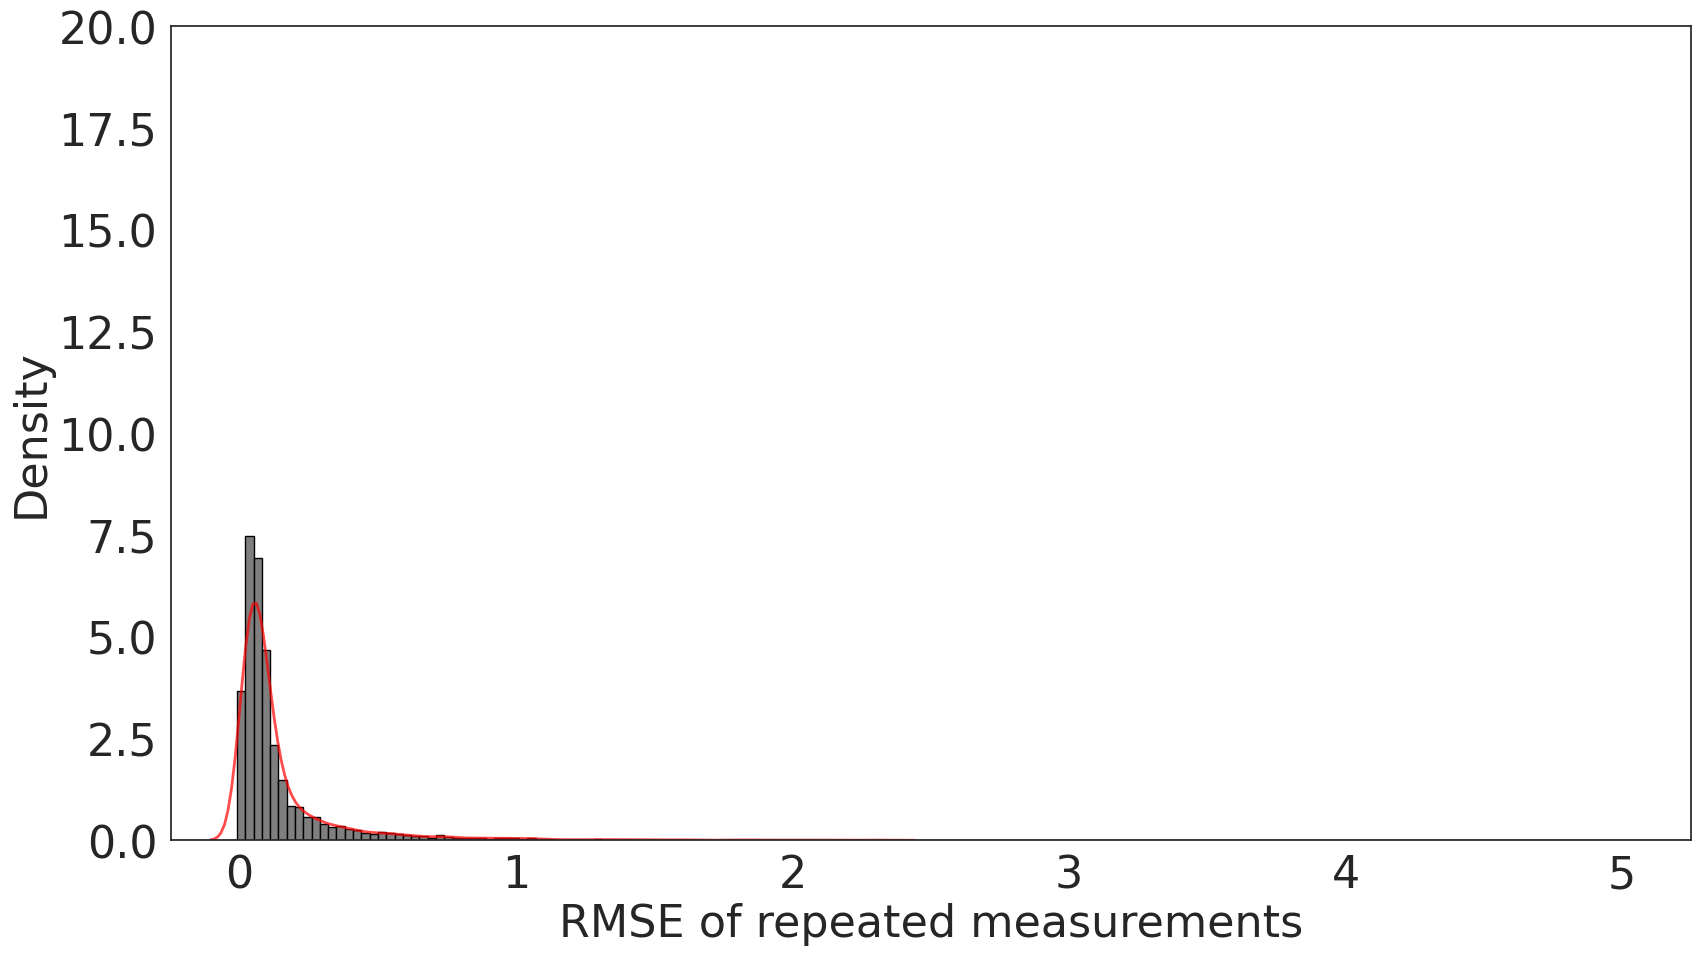

Number of expression dedup entries that had dups: 10441


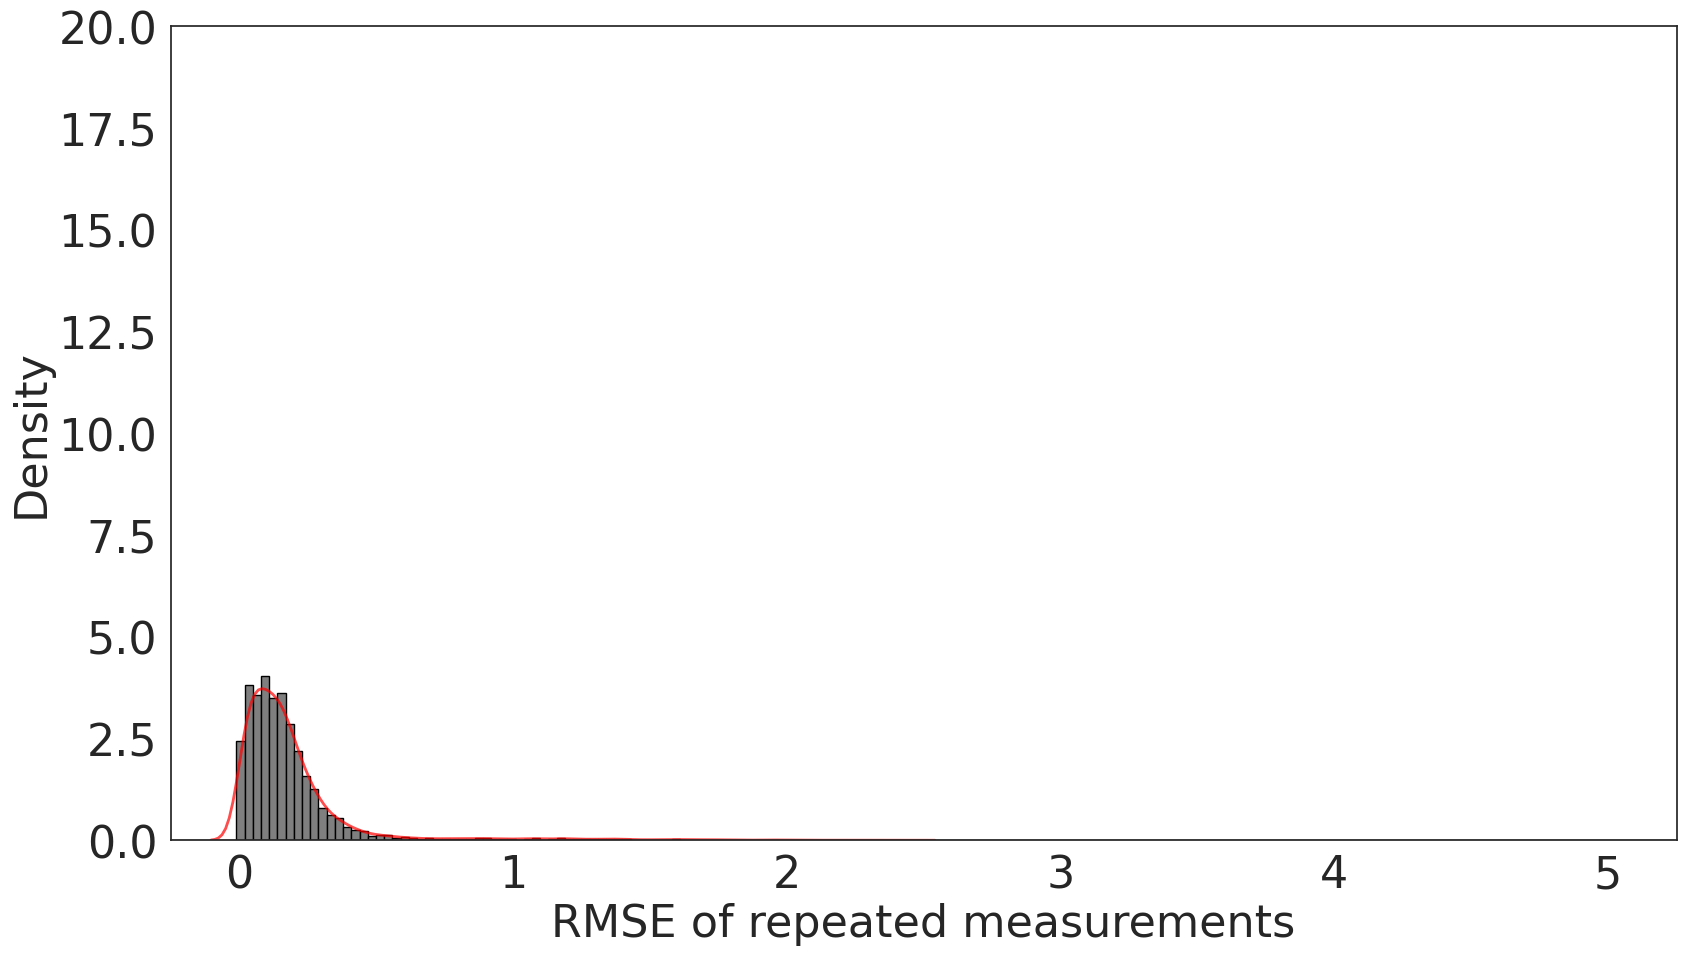

In [42]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_value_distribution(df, value_col:str, save_as:str=None):
    """ 
    Plots the given value distribution. 
    """
    sns.set_theme(style="white")
    plt.figure(figsize=(16, 9))

    # Create histogram
    bins = np.arange(-0.25, 5.25, 0.03)
    plt.hist(df[value_col], 
             bins=bins, 
             density=True,
             color='tab:grey',
             edgecolor='black')

    sns.kdeplot(df[value_col], color='red', linewidth=2, alpha=0.7)

    fontsize = 32
    plt.tight_layout()
    plt.xlim(-0.25, 5.25)
    plt.ylim(0, 20)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.xlabel("RMSE of repeated measurements", fontsize=fontsize)
    plt.ylabel("Density", fontsize=fontsize)
    plt.show()


data_dir = '../../data/dms'
dups_only_b_combined_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_binding_dups_rmse.csv"), sep=',', header=0)
print('Number of binding dedup entries that had dups:', len(dups_only_b_combined_df))
plot_value_distribution(dups_only_b_combined_df, "rmse_binding")

dups_only_e_combined_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_expression_dups_rmse.csv"), sep=',', header=0)
print('Number of expression dedup entries that had dups:', len(dups_only_e_combined_df))
plot_value_distribution(dups_only_e_combined_df, "rmse_expression")

## Model RMSE

Let's try to make a plot that compares these measured pseudo RMSE values with those from our models. First, we need to rerun the best and last epoch models and extract the individual RMSE values per sample.

In [7]:
import os
import sys
import tqdm
import time
import torch
import random
import datetime
import pandas as pd
import numpy as np
from typing import Union
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel

def load_model(saved_model_pth, device):
    saved_state = torch.load(saved_model_pth, map_location=device)

    model_state = saved_state['model_state_dict']
    optimizer_state = saved_state['optimizer_state_dict']

    epoch = saved_state['epoch']
    loss = saved_state['loss']

    print(f"Loaded in model from {saved_model_pth}, saved at epoch {epoch}, rmse loss {loss}")
    return model_state, optimizer_state, epoch, loss

class DMSDataset(Dataset):
    """ Binding or Expression DMS Dataset, single target. """
    
    def __init__(self, csv_file:str, result_tag:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding or expression target,
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
            self.target = 'ACE2-binding_affinity' if 'binding' in result_tag else 'RBD_expression'
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df[self.target][idx]

### ESM-FCN

In [8]:
class FCN(nn.Module):
    """ Fully Connected Network """

    def __init__(self,
                 fcn_input_size,    # The number of input features
                 fcn_hidden_size,   # The number of features in hidden layer of FCN.
                 fcn_num_layers):   # The number of fcn layers  
        super().__init__()

        # Creating a list of layers for the FCN
        # Subsequent layers after 1st should be equal to hidden_size for input_size
        layers = []
        input_size = fcn_input_size

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(input_size, fcn_hidden_size))
            layers.append(nn.ReLU())
            input_size = fcn_hidden_size

        # FCN layers
        self.fcn = nn.Sequential(*layers)

        # FCN output layer 
        self.out = nn.Linear(fcn_hidden_size, 1)

    def forward(self, x):
        fcn_out = self.fcn(x)
        prediction = self.out(fcn_out).squeeze(1)  # [batch_size]
        
        return prediction

# ESM-FCN
class ESM_FCN(nn.Module):
    def __init__(self, esm, fcn):
        super().__init__()
        self.esm = esm
        self.fcn = fcn

    def forward(self, x):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**x).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_cls_embedding = esm_last_hidden_state[:, 0, :]  # CLS token embedding (sequence-level representations), [batch_size, embedding_dim]
            output = self.fcn(esm_cls_embedding)
        return output
    
# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    rmse_dict = {
        "seq_id": [],
        "mse": [],
        "rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        preds = model(tokenized_seqs)
        batch_losses = loss_fn(preds, targets)
        batch_loss = sum(batch_losses)
        batch_loss.backward()

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            preds = model(tokenized_seqs)
            batch_losses = loss_fn(preds, targets)

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("test")

    df = pd.DataFrame.from_dict(rmse_dict)
    df.to_csv(save_as, index=False)
    print(df)

# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
result_tag = 'binding' # specify expression or binding
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_fcn'

run_dir_binding = os.path.join(results_dir, f'adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54')
save_as_binding = os.path.join(run_dir_binding, f"all_rmse_best_saved.csv")
saved_model_pth_binding = os.path.join(run_dir_binding, "best_saved_model.pth")

run_dir_expression = os.path.join(results_dir, f'adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15')
save_as_expression = os.path.join(run_dir_expression, f"all_rmse_best_saved.csv")
saved_model_pth_expression = os.path.join(run_dir_expression, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# FCN input
size = 320
fcn_input_size = size  
fcn_hidden_size = size
fcn_num_layers = 5
fcn = FCN(fcn_input_size, fcn_hidden_size, fcn_num_layers)

model = ESM_FCN(esm, fcn)

# Run
print("== BINDING ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_binding, saved_model_pth_binding)
print("== EXPRESSION ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_expression, saved_model_pth_expression)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


== BINDING ==
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/best_saved_model.pth, saved at epoch 965, rmse loss 0.518519043711583


Testing data: 100%|| 322/322 [00:15<00:00, 20.78it/s]


                                      seq_id           mse      rmse   mode
0                SARS-CoV-2-S19E_E141G_N157A  5.112498e-05  0.007150  train
1                SARS-CoV-2-T63F_Y178V_S184L  4.797955e-03  0.069267  train
2                     SARS-CoV-2-W106A_G146C  4.999415e-04  0.022359  train
3           SARS-CoV-2-A18C_R25V_L122T_P149R  4.512083e-04  0.021242  train
4                       SARS-CoV-2-D59W_P96S  1.180933e-03  0.034365  train
...                                      ...           ...       ...    ...
102718      SARS-CoV-2-V11A_V32G_W106G_G146H  2.298817e-05  0.004795   test
102719  SARS-CoV-2-T3G_K48P_G83E_S147V_V173S  6.547928e-07  0.000809   test
102720                       SARS-CoV-2-K94H  2.733143e-03  0.052279   test
102721           SARS-CoV-2-T46L_S139T_F185Q  7.951086e-02  0.281977   test
102722      SARS-CoV-2-A14P_N58V_T140V_C150F  2.409552e-01  0.490872   test

[102723 rows x 4 columns]
== EXPRESSION ==
Loaded in model from ../../results/run_resul

Testing data: 100%|| 322/322 [00:15<00:00, 20.80it/s]


                                       seq_id       mse      rmse   mode
0                  SARS-CoV-2-C6V_Q144E_F156G  0.556356  0.745893  train
1              SARS-CoV-2-I28V_S41T_V77T_Q84R  0.536479  0.732447  train
2                      SARS-CoV-2-N107T_G146Y  1.683515  1.297503  train
3                         SARS-CoV-2-N4R_A81Q  0.984809  0.992375  train
4       SARS-CoV-2-S41Y_F62L_Q79G_T100H_N130D  2.001437  1.414722  train
...                                       ...       ...       ...    ...
102718             SARS-CoV-2-S29E_L95Q_N120K  3.562200  1.887379   test
102719             SARS-CoV-2-Y50T_N64S_N120P  0.206611  0.454545   test
102720                   SARS-CoV-2-T15M_P96S  4.421156  2.102654   test
102721      SARS-CoV-2-A22L_G101I_E135G_Q168I  3.153783  1.775889   test
102722              SARS-CoV-2-T3S_D34L_A105F  2.817356  1.678498   test

[102723 rows x 4 columns]


### ESM-GCN

In [9]:
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

class GraphSAGE(nn.Module):
    def __init__(self, input_channels, hidden_channels):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.output = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        output = self.output(x).squeeze(1)
        return output

class ESM_GCN(nn.Module):
    def __init__(self, esm, gcn):
        super().__init__()
        self.esm = esm
        self.gcn = gcn

    def forward(self, tokenized_seqs, targets):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_aa_embedding = esm_last_hidden_state[:, 1:-1, :] # Amino Acid-level representations, [batch_size, sequence_length-2, embedding_dim], excludes 1st and last tokens
            
            # Graph Construction
            graphs = []
            for embedding, target in zip(esm_aa_embedding, targets):
                edges = [(i, i+1) for i in range(embedding.size(0) - 1)]
                edge_index = torch.tensor(edges, dtype=torch.int64).t().contiguous()

                graphs.append(Data(
                    x=embedding, 
                    edge_index=edge_index,
                    y=torch.tensor([target], dtype=torch.float32)
                ))

            batch_graph = Batch.from_data_list(graphs).to(device)
            output = self.gcn(batch_graph.x, batch_graph.edge_index, batch_graph.batch)

        return output, batch_graph.y

# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    rmse_dict = {
        "seq_id": [],
        "mse": [],
        "rmse": [],
        "mode": []
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        preds, y = model(tokenized_seqs, targets)
        batch_losses = loss_fn(preds, y)
        batch_loss = sum(batch_losses)
        batch_loss.backward()

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            preds, y = model(tokenized_seqs, targets)
            batch_losses = loss_fn(preds, y)

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("test")

    df = pd.DataFrame.from_dict(rmse_dict)
    df.to_csv(save_as, index=False)
    print(df)

# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
result_tag = 'binding' # specify expression or binding
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_gcn'

run_dir_binding = os.path.join(results_dir, f'adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53')
save_as_binding = os.path.join(run_dir_binding, f"all_rmse_best_saved.csv")
saved_model_pth_binding = os.path.join(run_dir_binding, "best_saved_model.pth")

run_dir_expression = os.path.join(results_dir, f'adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-07_20-54')
save_as_expression = os.path.join(run_dir_expression, f"all_rmse_best_saved.csv")
saved_model_pth_expression = os.path.join(run_dir_expression, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# GraphSAGE input
size = 320
input_channels = size # Number of input channels (dimensions of the embeddings)
hidden_channels = size
gcn = GraphSAGE(input_channels, hidden_channels)

model = ESM_GCN(esm, gcn)

# Run
print("== BINDING ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_binding, saved_model_pth_binding)
print("== EXPRESSION ==")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, save_as_expression, saved_model_pth_expression)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


== BINDING ==
Loaded in model from ../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53/best_saved_model.pth, saved at epoch 674, rmse loss 0.5200985174935644


Testing data: 100%|| 322/322 [00:18<00:00, 17.53it/s]


                                      seq_id       mse      rmse   mode
0                SARS-CoV-2-S19E_E141G_N157A  0.000029  0.005367  train
1                SARS-CoV-2-T63F_Y178V_S184L  0.000874  0.029561  train
2                     SARS-CoV-2-W106A_G146C  0.000082  0.009082  train
3           SARS-CoV-2-A18C_R25V_L122T_P149R  0.003412  0.058413  train
4                       SARS-CoV-2-D59W_P96S  0.001610  0.040120  train
...                                      ...       ...       ...    ...
102718      SARS-CoV-2-V11A_V32G_W106G_G146H  0.024368  0.156104   test
102719  SARS-CoV-2-T3G_K48P_G83E_S147V_V173S  0.001996  0.044676   test
102720                       SARS-CoV-2-K94H  0.000071  0.008451   test
102721           SARS-CoV-2-T46L_S139T_F185Q  0.156655  0.395797   test
102722      SARS-CoV-2-A14P_N58V_T140V_C150F  0.263090  0.512923   test

[102723 rows x 4 columns]
== EXPRESSION ==
Loaded in model from ../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expressi

Testing data: 100%|| 322/322 [00:18<00:00, 17.61it/s]


                                       seq_id       mse      rmse   mode
0                  SARS-CoV-2-C6V_Q144E_F156G  0.402701  0.634587  train
1              SARS-CoV-2-I28V_S41T_V77T_Q84R  0.406848  0.637846  train
2                      SARS-CoV-2-N107T_G146Y  1.833404  1.354033  train
3                         SARS-CoV-2-N4R_A81Q  0.945687  0.972465  train
4       SARS-CoV-2-S41Y_F62L_Q79G_T100H_N130D  1.953524  1.397685  train
...                                       ...       ...       ...    ...
102718             SARS-CoV-2-S29E_L95Q_N120K  3.726569  1.930432   test
102719             SARS-CoV-2-Y50T_N64S_N120P  0.312231  0.558776   test
102720                   SARS-CoV-2-T15M_P96S  4.786786  2.187872   test
102721      SARS-CoV-2-A22L_G101I_E135G_Q168I  2.724219  1.650521   test
102722              SARS-CoV-2-T3S_D34L_A105F  2.063234  1.436396   test

[102723 rows x 4 columns]


## Figures - Histogram Plot (Stacked)
### ESM-FCN

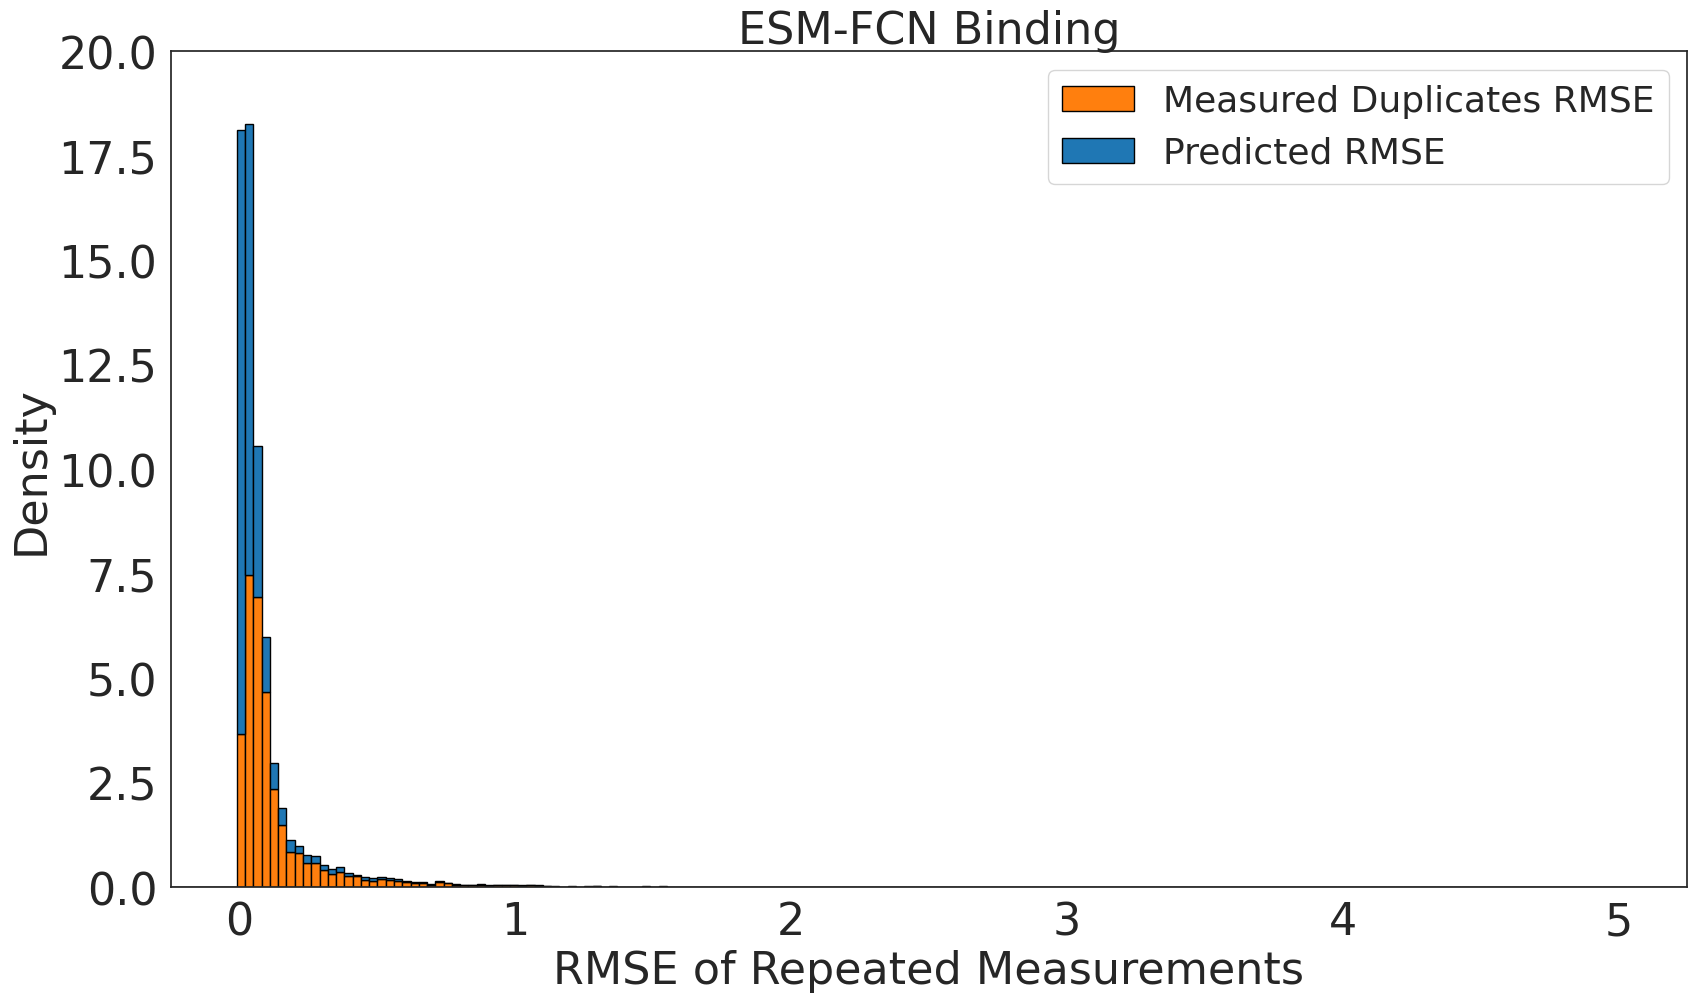

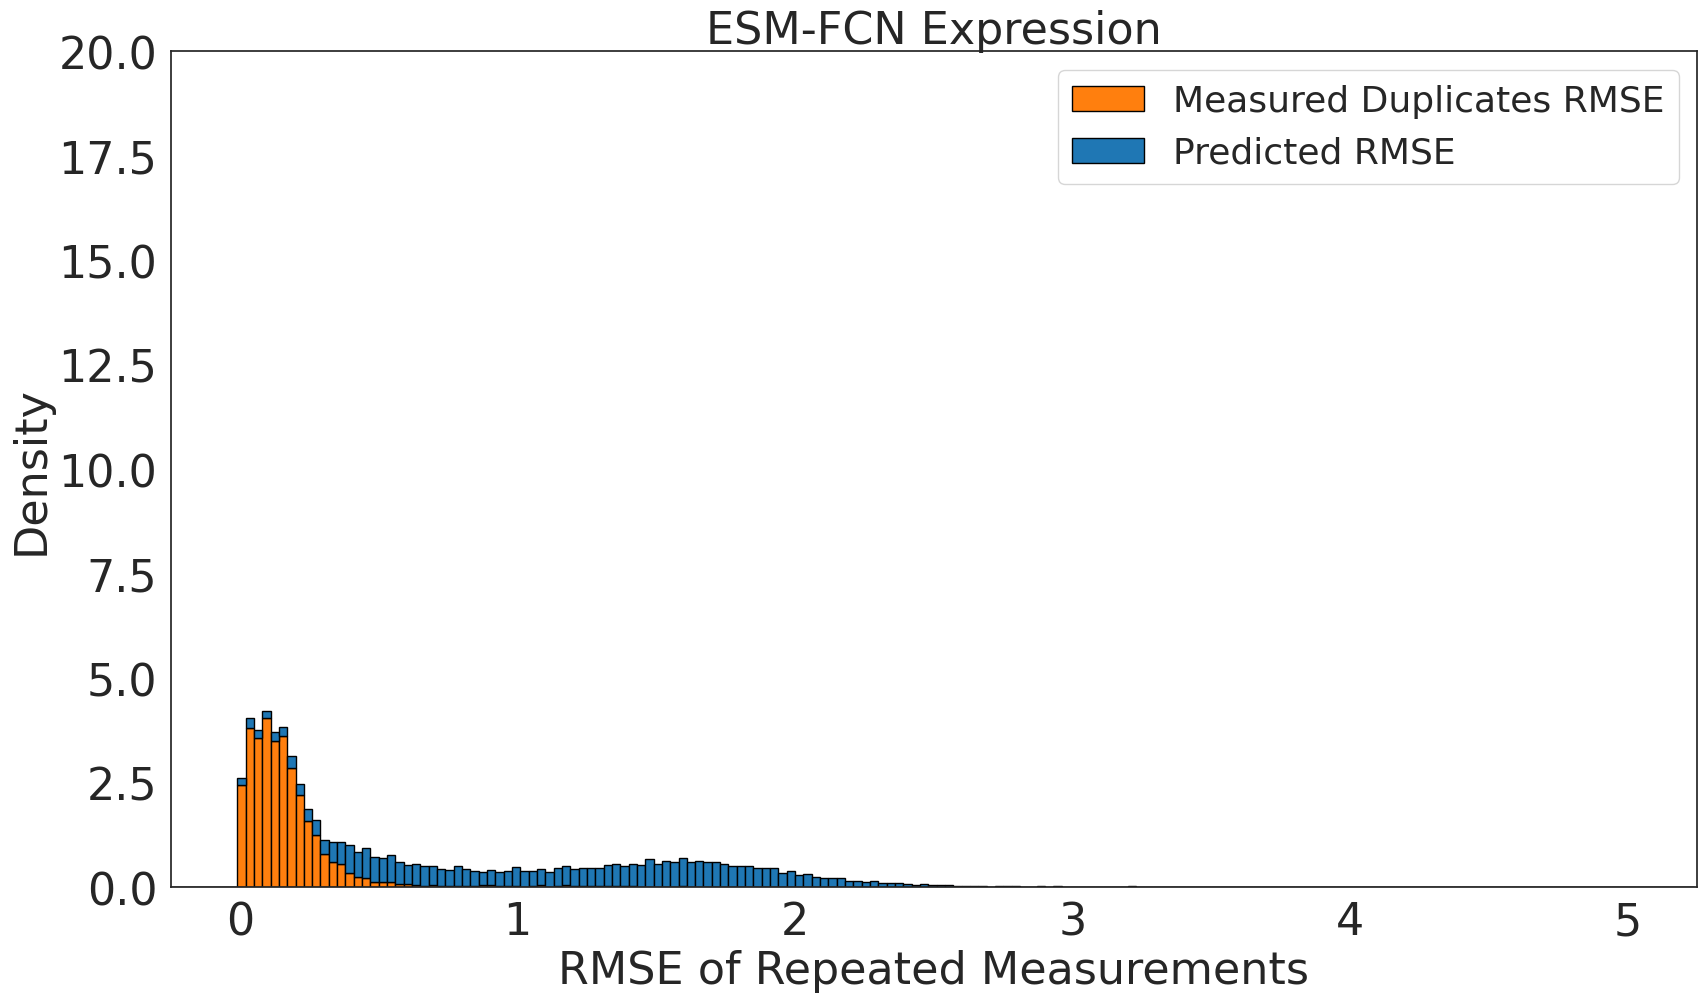

In [50]:
def plot_rmse_value_distribution(merged_df, dup_df_col, rmse_df_col, title, save_as):
    """ 
    Plots the given value distribution as a stacked histogram. 
    """
    sns.set_theme(style="white")
    plt.figure(figsize=(16, 9))

    # Create stacked histogram with individual normalization
    bins = np.arange(-0.25, 5.25, 0.03)
    rmse_values = merged_df[rmse_df_col]
    dup_values = merged_df[dup_df_col]

    # Normalize each dataset separately
    rmse_density, _ = np.histogram(rmse_values, bins=bins, density=True)
    dup_density, _ = np.histogram(dup_values, bins=bins, density=True)

    # Create stacked data with orange on the bottom
    plt.bar(bins[:-1], dup_density, width=np.diff(bins), align='edge', label='Measured Duplicates RMSE', color='tab:orange', edgecolor='black')
    plt.bar(bins[:-1], rmse_density, width=np.diff(bins), align='edge', bottom=dup_density, label='Predicted RMSE', color='tab:blue', edgecolor='black')

    # Set axis labels and ranges
    fontsize = 32
    plt.tight_layout()
    plt.xlim(-0.25, 5.25)
    plt.ylim(0, 20)  # Adjust based on observed densities
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.xlabel("RMSE of Repeated Measurements", fontsize=fontsize)
    plt.ylabel("Density", fontsize=fontsize)
    plt.title(title, fontsize=fontsize)
    plt.legend(fontsize=fontsize-6)
    plt.savefig(save_as, format='pdf')
    plt.savefig(save_as.replace('.pdf', '.png'), format='png')


dups_only_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD_binding_dups_rmse.csv", sep=',', header=0, usecols=['label', 'rmse_binding'])
rmse_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/all_rmse_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    rmse_df,
    dups_only_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
plot_rmse_value_distribution(merged_df, "rmse_binding", "rmse", "ESM-FCN Binding", "../../results/plots/measured_vs_predicted/esm_fcn_binding-rmse_dups_hist.pdf")

dups_only_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD_expression_dups_rmse.csv", sep=',', header=0, usecols=['label', 'rmse_expression'])
rmse_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/all_rmse_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    rmse_df,
    dups_only_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
plot_rmse_value_distribution(merged_df, "rmse_expression", "rmse", "ESM-FCN Expression", "../../results/plots/measured_vs_predicted/esm_fcn_expression-rmse_dups_hist.pdf")

### ESM-GCN
New double relu. Single relu version in progress if results end up better.

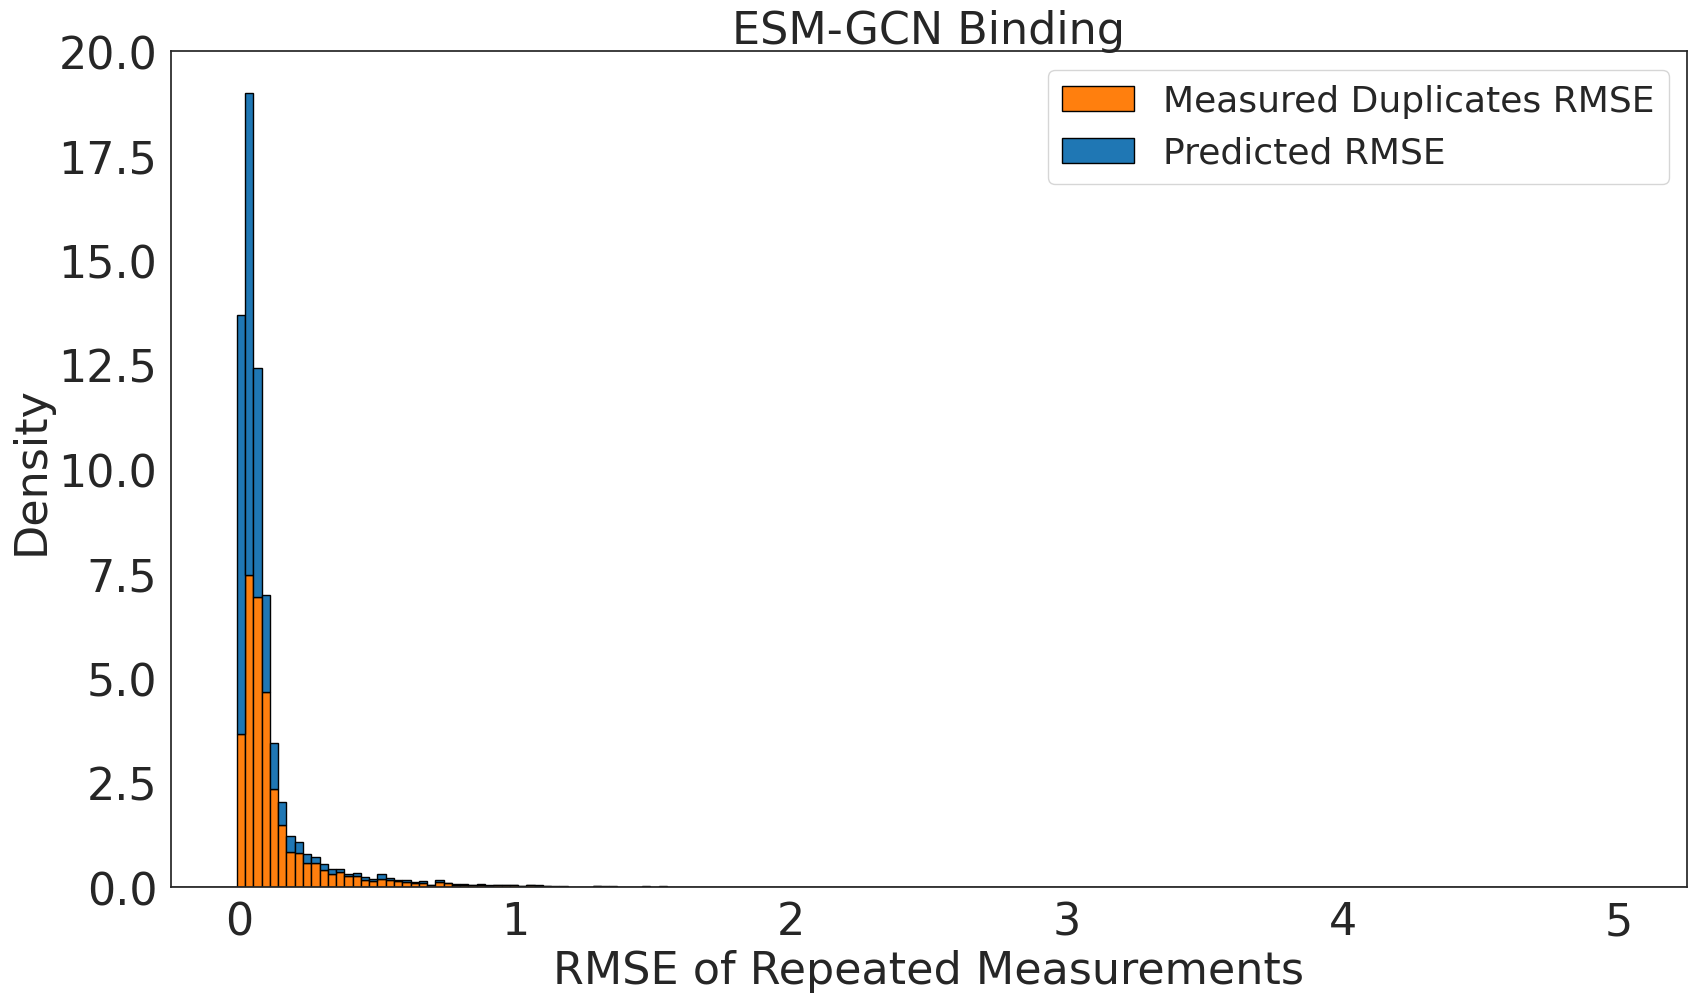

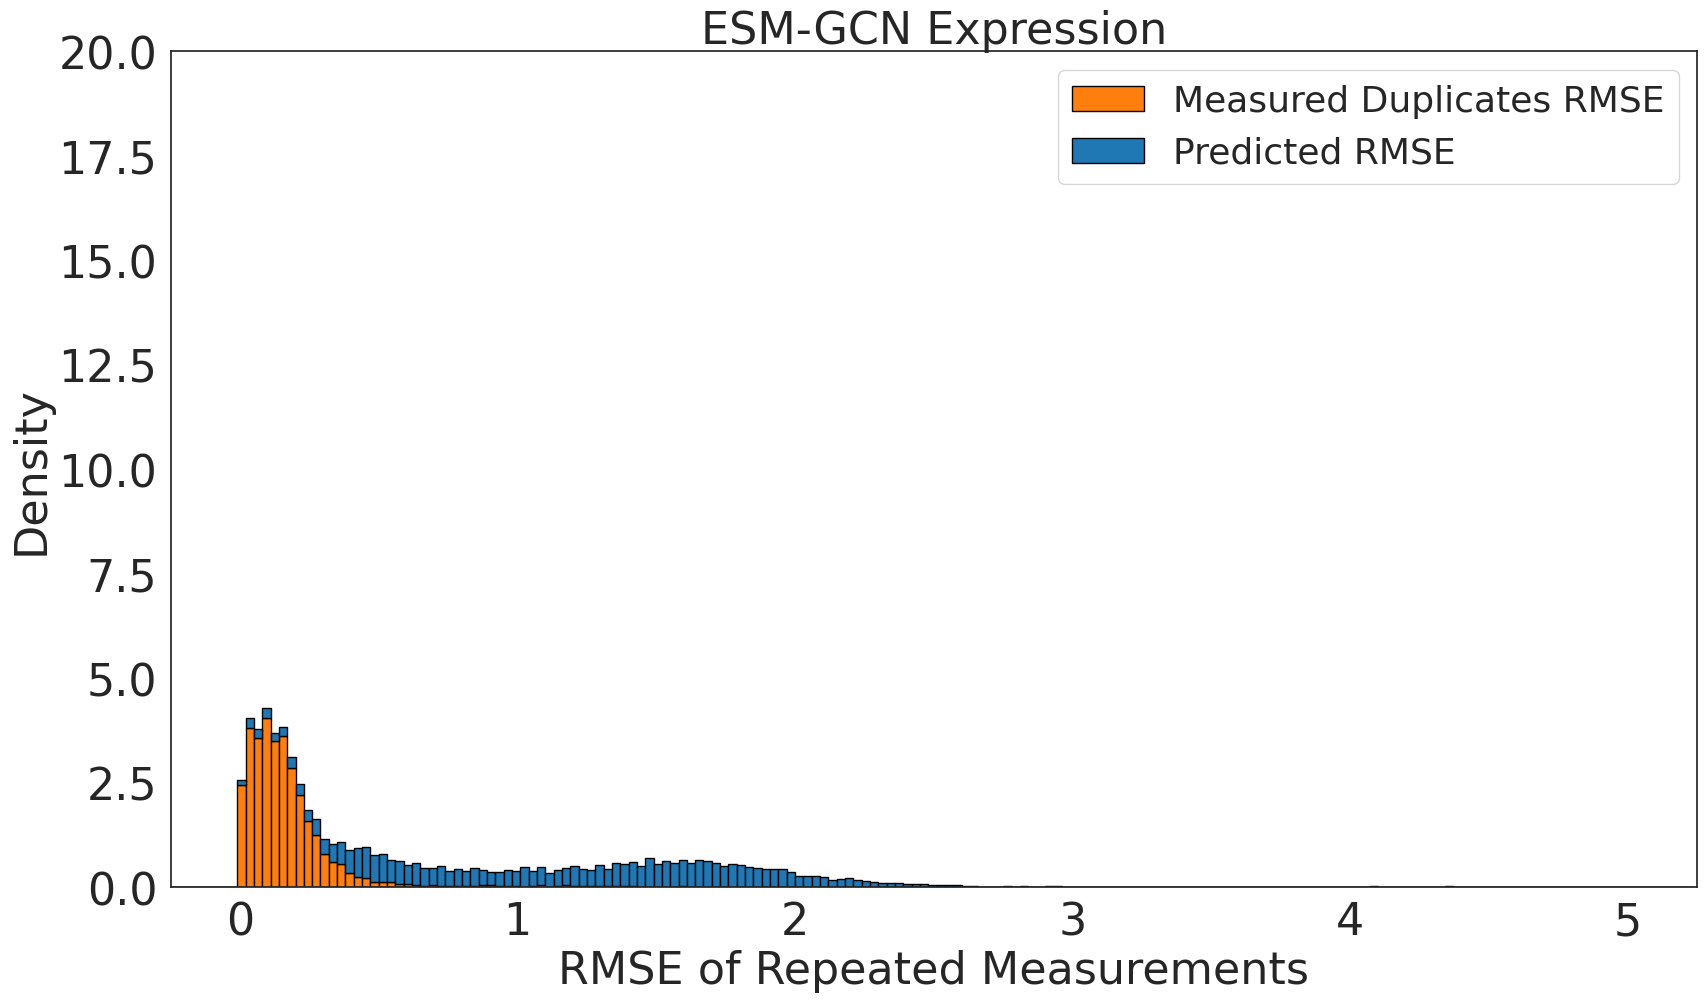

In [48]:
dups_only_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD_binding_dups_rmse.csv", sep=',', header=0, usecols=['label', 'rmse_binding'])
rmse_df = pd.read_csv("../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53/all_rmse_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    rmse_df,
    dups_only_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
plot_rmse_value_distribution(merged_df, "rmse_binding", "rmse", "ESM-GCN Binding", "../../results/plots/measured_vs_predicted/esm_gcn_binding-rmse_dups_hist.pdf")

dups_only_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD_expression_dups_rmse.csv", sep=',', header=0, usecols=['label', 'rmse_expression'])
rmse_df = pd.read_csv("../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-07_20-54/all_rmse_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    rmse_df,
    dups_only_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
plot_rmse_value_distribution(merged_df, "rmse_expression", "rmse", "ESM-GCN Expression", "../../results/plots/measured_vs_predicted/esm_gcn_expression-rmse_dups_hist.pdf")